# Imports

In [61]:
import torch
from torch import nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import time
from IPython.display import display, clear_output

# ML-100K Dataset

In [62]:
def read_data_ml100k():
    data_dir = 'ml-100k'
    names = ['user_id', 'item_id', 'rating', 'timestamp']
    data = pd.read_csv(os.path.join(data_dir, 'u.data'), sep='\t',
                       names=names, engine='python')
    num_users = data.user_id.unique().shape[0]
    num_items = data.item_id.unique().shape[0]
    return data, num_users, num_items

## Statistics of Dataset

In [63]:
data, num_users, num_items = read_data_ml100k()
sparsity = 1 - len(data) / (num_users * num_items)
print(f'number of users: {num_users}, number of items: {num_items}')
print(f'matrix sparsity: {sparsity:f}')
print(data.head(5))

number of users: 943, number of items: 1682
matrix sparsity: 0.936953
   user_id  item_id  rating  timestamp
0      196      242       3  881250949
1      186      302       3  891717742
2       22      377       1  878887116
3      244       51       2  880606923
4      166      346       1  886397596


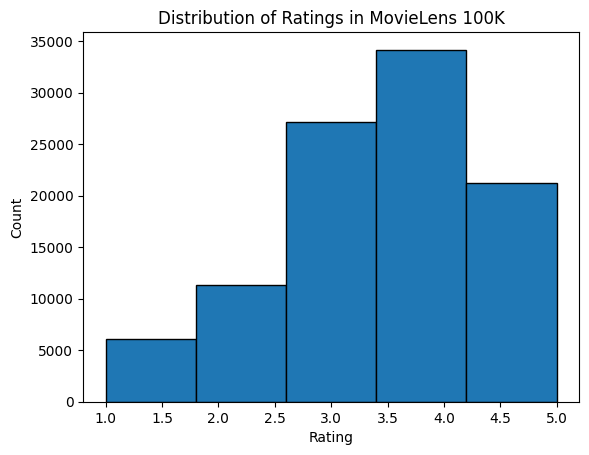

In [64]:
plt.hist(data['rating'], bins=5, ec='black')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.title('Distribution of Ratings in MovieLens 100K')
plt.show()

## Splitting Dataset

In [65]:
def split_data_ml100k(data, num_users, num_items,
                      split_mode='random', test_ratio=0.1):
    """Split the dataset in random mode or seq-aware mode."""
    if split_mode == 'seq-aware':
        train_items, test_items, train_list = {}, {}, []
        for line in data.itertuples():
            u, i, rating, time = line[1], line[2], line[3], line[4]
            train_items.setdefault(u, []).append((u, i, rating, time))
            if u not in test_items or test_items[u][-1] < time:
                test_items[u] = (i, rating, time)
        for u in range(1, num_users + 1):
            train_list.extend(sorted(train_items[u], key=lambda k: k[3]))
        test_data = [(key, *value) for key, value in test_items.items()]
        train_data = [item for item in train_list if item not in test_data]
        train_data = pd.DataFrame(train_data)
        test_data = pd.DataFrame(test_data)
    else:
        mask = [True if x == 1 else False for x in np.random.uniform(
            0, 1, (len(data))) < 1 - test_ratio]
        neg_mask = [not x for x in mask]
        train_data, test_data = data[mask], data[neg_mask]
    return train_data, test_data

## Loading Data

In [66]:
def load_data_ml100k(data, num_users, num_items, feedback='explicit'):
    users, items, scores = [], [], []
    inter = np.zeros((num_items, num_users)) if feedback == 'explicit' else {}
    for line in data.itertuples():
        user_index, item_index = int(line[1] - 1), int(line[2] - 1)
        score = int(line[3]) if feedback == 'explicit' else 1
        users.append(user_index)
        items.append(item_index)
        scores.append(score)
        if feedback == 'implicit':
            inter.setdefault(user_index, []).append(item_index)
        else:
            inter[item_index, user_index] = score
    return users, items, scores, inter

In [67]:
def split_and_load_ml100k(split_mode='seq-aware', feedback='explicit',
                          test_ratio=0.1, batch_size=256):
    data, num_users, num_items = read_data_ml100k()
    train_data, test_data = split_data_ml100k(
        data, num_users, num_items, split_mode, test_ratio)
    train_u, train_i, train_r, _ = load_data_ml100k(
        train_data, num_users, num_items, feedback)
    test_u, test_i, test_r, _ = load_data_ml100k(
        test_data, num_users, num_items, feedback)
    train_set = torch.utils.data.TensorDataset(
        torch.tensor(train_u, dtype=torch.long),
        torch.tensor(train_i, dtype=torch.long),
        torch.tensor(train_r, dtype=torch.float32))
    test_set = torch.utils.data.TensorDataset(
        torch.tensor(test_u, dtype=torch.long),
        torch.tensor(test_i, dtype=torch.long),
        torch.tensor(test_r, dtype=torch.float32))
    train_iter = torch.utils.data.DataLoader(
        train_set, shuffle=True, batch_size=batch_size)
    test_iter = torch.utils.data.DataLoader(
        test_set, batch_size=batch_size)
    return num_users, num_items, train_iter, test_iter

# Matrix Factorization

In [68]:
class MF(nn.Module):
    def __init__(self, num_factors, num_users, num_items):
        super(MF, self).__init__()
        self.P = nn.Embedding(num_users, num_factors)
        self.Q = nn.Embedding(num_items, num_factors)
        self.user_bias = nn.Embedding(num_users, 1)
        self.item_bias = nn.Embedding(num_items, 1)
        # Initialize weights with normal distribution (std=0.01)
        nn.init.normal_(self.P.weight, std=0.01)
        nn.init.normal_(self.Q.weight, std=0.01)
        nn.init.normal_(self.user_bias.weight, std=0.01)
        nn.init.normal_(self.item_bias.weight, std=0.01)

    def forward(self, user_id, item_id):
        P_u = self.P(user_id)
        Q_i = self.Q(item_id)
        b_u = self.user_bias(user_id).squeeze()
        b_i = self.item_bias(item_id).squeeze()
        outputs = (P_u * Q_i).sum(dim=1) + b_u + b_i
        return outputs

## Evaluation Measures

In [69]:
def evaluator(net, test_iter, devices):
    """Evaluate RMSE on test set."""
    net.eval()
    device = torch.device(devices[0] if isinstance(devices, list) else devices)
    net = net.to(device)
    rmse_list = []
    with torch.no_grad():
        for users, items, ratings in test_iter:
            users = users.to(device)
            items = items.to(device)
            ratings = ratings.to(device)
            preds = net(users, items)
            rmse = torch.sqrt(((preds - ratings) ** 2).mean())
            rmse_list.append(rmse.item())
    net.train()
    return float(np.mean(rmse_list))

## Training and Evaluating Model

In [70]:
def set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
    """Set the axes for matplotlib.

    Defined in :numref:`sec_calculus`"""
    axes.set_xlabel(xlabel), axes.set_ylabel(ylabel)
    axes.set_xscale(xscale), axes.set_yscale(yscale)
    axes.set_xlim(xlim),     axes.set_ylim(ylim)
    if legend:
        axes.legend(legend)
    axes.grid()

class Animator:  #@save
    """For plotting data in animation."""
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1,
                 figsize=(3.5, 2.5)):
        # Incrementally plot multiple lines
        if legend is None:
            legend = []
        self.fig, self.axes = plt.subplots(nrows, ncols, figsize=figsize)
        if nrows * ncols == 1:
            self.axes = [self.axes, ]
        # Use a lambda function to capture arguments
        self.config_axes = lambda: set_axes(
            self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend)
        self.X, self.Y, self.fmts = None, None, fmts

    def add(self, x, y):
        # Add multiple data points into the figure
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
        if not hasattr(x, "__len__"):
            x = [x] * n
        if not self.X:
            self.X = [[] for _ in range(n)]
        if not self.Y:
            self.Y = [[] for _ in range(n)]
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
        self.axes[0].cla()
        for x, y, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x, y, fmt)
        self.config_axes()
        display(self.fig)
        clear_output(wait=True)

class Accumulator:  #@save
    """For accumulating sums over `n` variables."""
    def __init__(self, n):
        self.data = [0.0] * n

    def add(self, *args):
        self.data = [a + float(b) for a, b in zip(self.data, args)]

    def reset(self):
        self.data = [0.0] * len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


def accuracy(y_hat, y):  #@save
    """Compute the number of correct predictions."""
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(dim=1)
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())

In [71]:
class Timer:
    """Recording multiple running times."""
    def __init__(self):
        self.times = []
        self.start()

    def start(self):
        """Start the timer."""
        self.tik = time.time()

    def stop(self):
        """Stop the timer and record the time in a list."""
        self.times.append(time.time() - self.tik)
        return self.times[-1]

    def avg(self):
        """Return the average time."""
        return sum(self.times) / len(self.times)

    def sum(self):
        """Return the sum of time."""
        return sum(self.times)

    def cumsum(self):
        """Return the accumulated time."""
        return np.array(self.times).cumsum().tolist()

In [72]:
def train_recsys_rating(net, train_iter, test_iter, loss, trainer, num_epochs,
                        devices=['cpu'], evaluator=None,
                        **kwargs):
    timer = Timer()
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0, 2],
                            legend=['train loss', 'test RMSE'])
    device = torch.device(devices[0] if isinstance(devices, list) else devices)
    net = net.to(device)
    net.train()
    
    for epoch in range(num_epochs):
        metric = Accumulator(3)
        for i, batch in enumerate(train_iter):
            timer.start()
            if isinstance(batch, (list, tuple)):
                users, items, ratings = [b.to(device) for b in batch]
                trainer.zero_grad()
                preds = net(users, items)
                l = loss(preds, ratings)
            else:
                batch = batch.to(device)
                trainer.zero_grad()
                preds = net(batch)
                l = loss(preds, batch)
            l.backward()
            trainer.step()
            batch_size = batch.shape[0] if not isinstance(batch, (list, tuple)) else users.shape[0]
            metric.add(l.item(), batch_size, batch_size)
            timer.stop()
        
        if len(kwargs) > 0:  # It will be used in section AutoRec
            test_rmse = evaluator(net, kwargs['inter_mat'], kwargs['inter_mat'], devices)
        else:
            test_rmse = evaluator(net, test_iter, devices)
        train_l = metric[0] / metric[1]
        animator.add(epoch + 1, (train_l, test_rmse))
    print(f'train loss {metric[0] / metric[1]:.3f}, '
          f'test RMSE {test_rmse:.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec '
          f'on {str(devices)}')

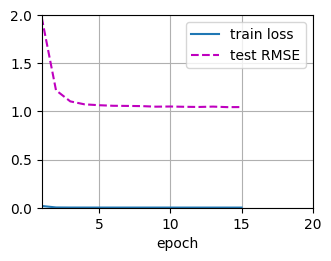

In [ ]:
num_users, num_items, train_iter, test_iter = split_and_load_ml100k(
    test_ratio=0.1, batch_size=512)
net = MF(30, num_users, num_items)
# Weight initialization is done in __init__ with nn.init.normal_(std=0.01)
lr, num_epochs, wd, optimizer = 0.002, 20, 1e-5, 'adam'
loss = nn.MSELoss()
trainer = torch.optim.Adam(net.parameters(), lr=lr, weight_decay=wd)
train_recsys_rating(net, train_iter, test_iter, loss, trainer, num_epochs,
                    ['cpu'], evaluator)

# AutoRec: Recommendation Systems with AutoEncoders

## Model

In [ ]:
class AutoRec(nn.Module):
    def __init__(self, num_hidden, num_users, dropout=0.05):
        super(AutoRec, self).__init__()
        self.encoder = nn.Linear(num_users, num_hidden, bias=True)
        self.activation = nn.Sigmoid()
        self.decoder = nn.Linear(num_hidden, num_users, bias=True)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input):
        hidden = self.dropout(self.activation(self.encoder(input)))
        pred = self.decoder(hidden)
        if self.training:  # Mask the gradient during training (PyTorch way)
            return pred * torch.sign(input)
        else:
            return pred

## Evaluator

In [ ]:
def evaluator(network, inter_matrix, test_data, devices):
    network.eval()
    device = torch.device(devices[0] if isinstance(devices, list) else devices)
    if isinstance(inter_matrix, np.ndarray):
        inter_matrix = torch.from_numpy(inter_matrix).float().to(device)
    if isinstance(test_data, np.ndarray):
        test_data = torch.from_numpy(test_data).float().to(device)
    with torch.no_grad():
        recons = network(inter_matrix)
    # Calculate the test RMSE
    rmse = torch.sqrt(torch.sum((test_data - torch.sign(test_data) * recons) ** 2)
                      / torch.sum(torch.sign(test_data) != 0))
    network.train()
    return float(rmse.item())

## Training and Evaluating Model

In [ ]:
devices = ['cpu']
# Load the MovieLens 100K dataset
df, num_users, num_items = read_data_ml100k()
train_data, test_data = split_data_ml100k(df, num_users, num_items)
_, _, _, train_inter_mat = load_data_ml100k(train_data, num_users, num_items)
_, _, _, test_inter_mat = load_data_ml100k(test_data, num_users, num_items)
train_inter_mat = torch.from_numpy(train_inter_mat).float()
test_inter_mat = torch.from_numpy(test_inter_mat).float()
train_iter = torch.utils.data.DataLoader(train_inter_mat, shuffle=True, batch_size=256)
test_iter = torch.utils.data.DataLoader(test_inter_mat, shuffle=False, batch_size=1024)
# Model initialization, training, and evaluation
net = AutoRec(500, num_users)
lr, num_epochs, wd, optimizer = 0.002, 25, 1e-5, 'adam'
loss = nn.MSELoss()
trainer = torch.optim.Adam(net.parameters(), lr=lr, weight_decay=wd)
train_recsys_rating(net, train_iter, test_iter, loss, trainer, num_epochs,
                    devices, evaluator, inter_mat=test_inter_mat)

TypeError: DataLoader.__init__() got an unexpected keyword argument 'last_batch'